# Euromonitor Entity Resolution — SKU → ITEM grouping

**Goal.** Group the euromonitor product listings into **ITEMs**, so every listing of the *same physical product* shares one `ITEM_ID` — entity resolution / record linkage across 19 countries.

**Approach.** Block → score → link with a zero-shot bi-encoder, then dedupe marketplace listings first and hard-link by barcode.


<style>
.rendered_html, .jp-RenderedHTMLCommon { font-size: 115%; }
</style>


## Dataset size

The raw export holds **71,623 listings**. The tiered dedupe (`06_dedupe.py`) collapses within-retailer duplicate marketplace listings (one title listed 143× on one retailer) to a single deliberate representative, leaving **61,404 representatives** — **10,219 duplicate listings removed (−14.3%)**.


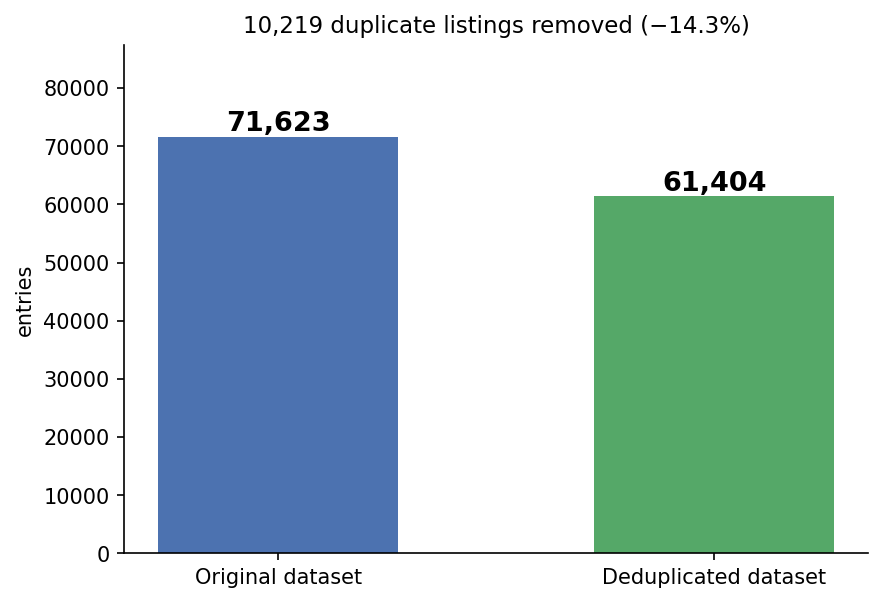

In [ ]:
from make_notebook import plot_dataset_sizes

plot_dataset_sizes()


## Regex examples — volume recovered from titles

Five titles and the volume the title regex recovered from each. `"500ml"`, `"1.89 l"`, and `"12 fl oz"` all normalize to single **ml** column.

| Title | Volume (text) | Single volume (ml) |
|---|---|---|
| The Juice Company Turmeric Immune Support Juice Shot 100ml | 100 ml | 100 |
| arifoglu thyme juice 500ml | 500 ml | 500 |
| Alkaline88 Alkaline Water, 101 Fl Oz, 1 Ct | 101 fl oz | 2985 |
| President's Choice Spicy Tomato Clam Cocktail \| 1.89 l | 1.89 l | 1890 |
| Mello Yello Zero - 12pk / 12 fl oz Cans | 12 fl oz | 355 |


## Duplicate examples — what the dedupe collapsed

Each row below is a retailer+title group that appeared **multiple times with different prices** — marketplace offers, not scrape glitches — collapsed to one representative by the dedupe.

| Retailer | Title | Times item appears | Distinct prices |
|---|---|---|---|
| mat.se | Cola incl. Pant | 5 | 5 |
| Carethy | Electrolyte Drink Lemongrass Citrus 1 l | 5 | 5 |
| Pavilions | North Coast Organic Apple Juice - 64 Fl. Oz. | 2 | 2 |
| Walmart | Sparkling Flavored Water ( Orchard Peach, 6 Pack) | 13 | 4 |
| Walmart | Oat Milk Cold Brew Latte, No Sugar Added & No Dairy, Organic & Non-GMO, Low Acidity & Vegan, 7 Fl. Oz. Cans | 2 | 2 |


## Target distribution by origin

The barcode label is our only supervised signal; the usable targets are the multi-retailer barcode groups (same barcode under ≥2 retailers ⇒ same product). This chart shows how those usable label groups are distributed by country — where the ground truth actually lives (`01g_usable_by_country.png`, step 01g). ~95% of groups are single-country; only ~5% cross a border.


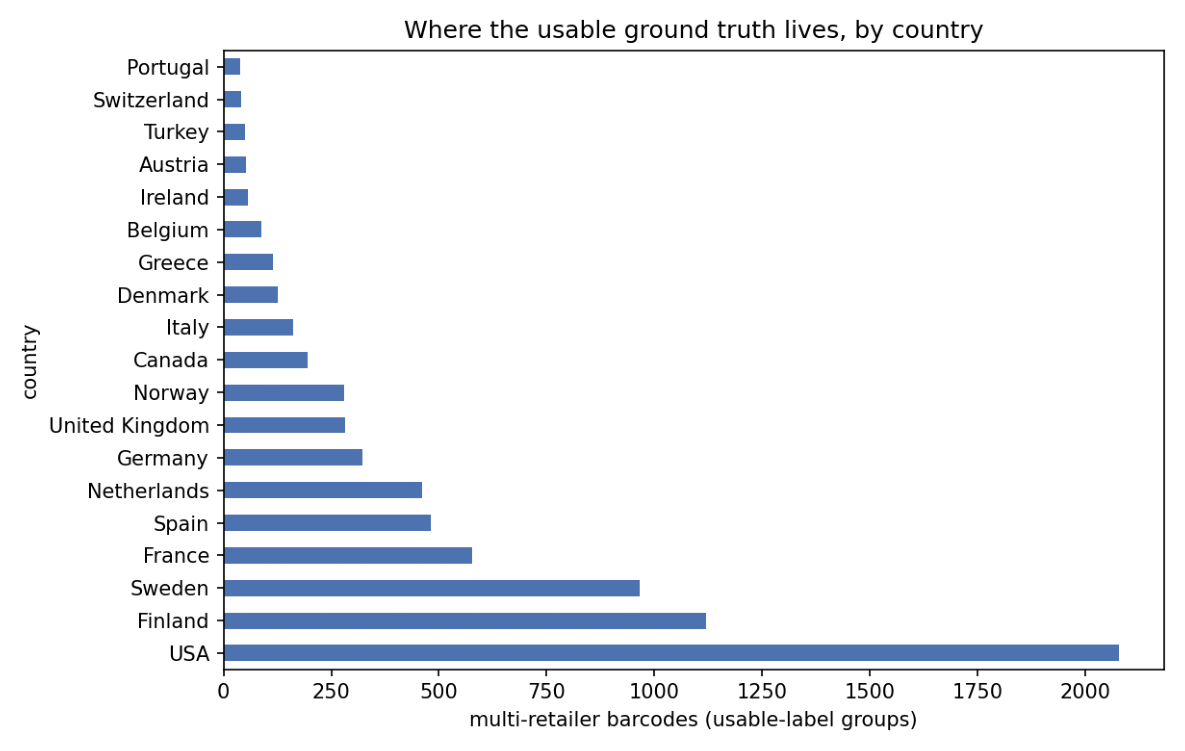

In [ ]:
from make_notebook import show_image

show_image("01g_usable_by_country.png")


## TF-IDF baseline scoring

Before the neural scorer, a cheaper **TF-IDF** cosine baseline on titles already separates same-barcode from cross-barcode ground-truth pairs (`04_tfidf_scores.png`, step 04). It is lexical, so it cannot bridge wording gaps; the semantic bi-encoder comes later.


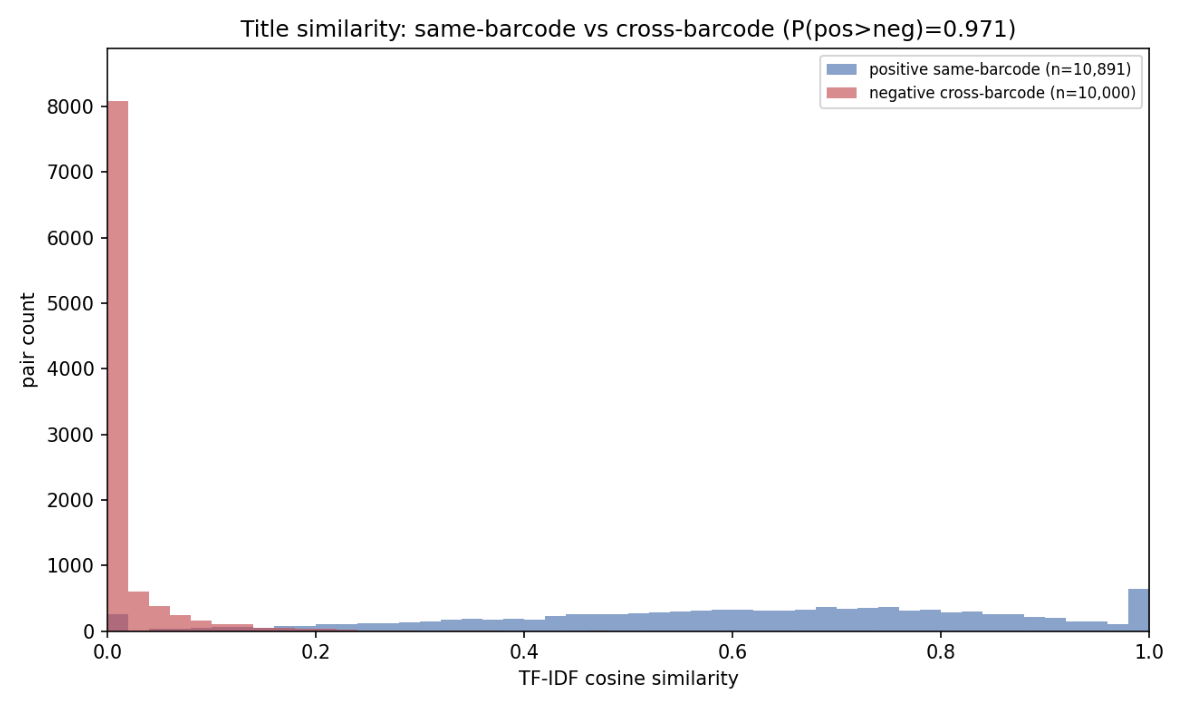

In [ ]:
from make_notebook import show_image

show_image("04_tfidf_scores.png")


## Conflicting barcodes on identical titles

But what happens if Retailer A and Retailer B both list the exact same product title (e.g., "Clearspring Organic Coconut Water 350ml"), but assign it *different* barcodes? 
(`06b_mislabeled_barcode_report.py`).


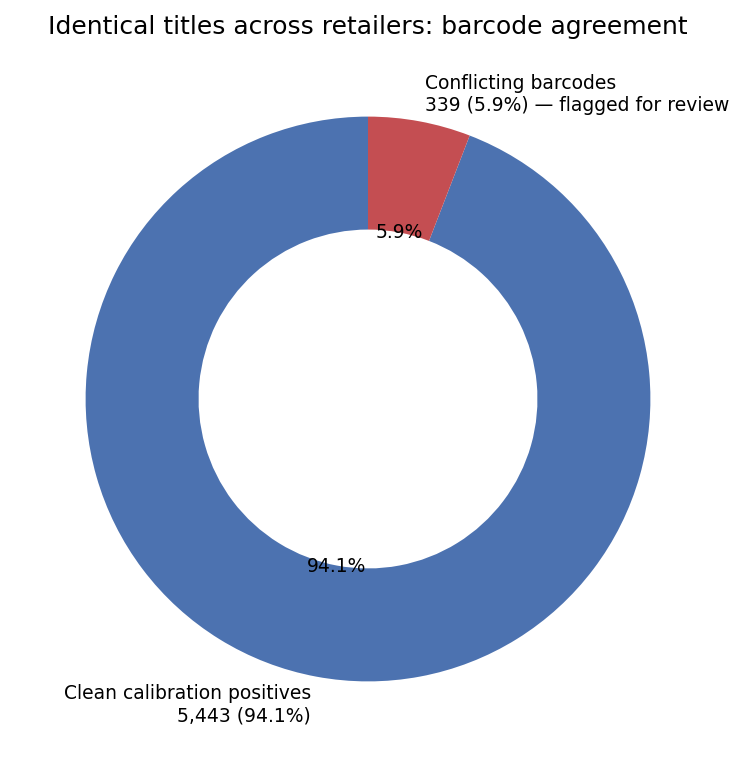

In [ ]:
from make_notebook import plot_barcode_audit

plot_barcode_audit()


## Macro mapping — 24 categories → 6 buckets

The strict Euromonitor categories roll up into six macro buckets used for blocking (`04b_macro_mapping.csv`):

| WATER | JUICE | CARBONATES | ENERGY_SPORTS | TEA_COFFEE | CONCENTRATES |
|---|---|---|---|---|---|
| Carbonated Bottled Water (1,743) · Functional Bottled Water (3,659) · Sparkling Flavoured Bottled Water (2,297) · Still Bottled Water (2,414) · Still Flavoured Bottled Water (883) | Coconut and Other Plant Waters (1,811) · Juice Drinks (up to 24% Juice) (4,021) · Nectars (2,133) · Not from Concentrate 100% Juice (9,000) · Reconstituted 100% Juice (1,272) | Lemonade/Lime (1,163) · Orange Carbonates (910) · Other Non-Cola Carbonates (5,909) · Reduced Sugar Cola Carbonates (542) · Regular Cola Carbonates (502) · Tonic Water/Mixers/Other Bitters (1,446) | Energy Drinks (4,675) · Sports Drinks (1,308) | Asian Speciality Drinks (10) · Carbonated RTD Tea and Kombucha (1,666) · RTD Coffee (3,535) · Still RTD Tea (2,624) | Liquid Concentrates (4,807) · Powder Concentrates (3,074) |


## Category audit — which granularity to block on

Step `04b` tested strict (24) vs macro (6) category granularity on the ground-truth pairs before choosing a block key:

- **T1 — true-pair match (blocking recall):** 93.0% of true pairs share the *strict* category vs 97.6% the *macro* bucket (chance baseline 7.1% / 19.8%) → **block on macro** (recall-first).
- **T2 — mutual information with the match label:** brand 0.649 > strict 0.438 > macro 0.375 → exact category adds little beyond brand.
- **T3 — Cramer's V with retailer:** strict 0.172 vs macro 0.233 → categories are fairly universal across retailers.

The figure shows the T1 match rates and the T2 MI bars (`04b_category_audit.png`).


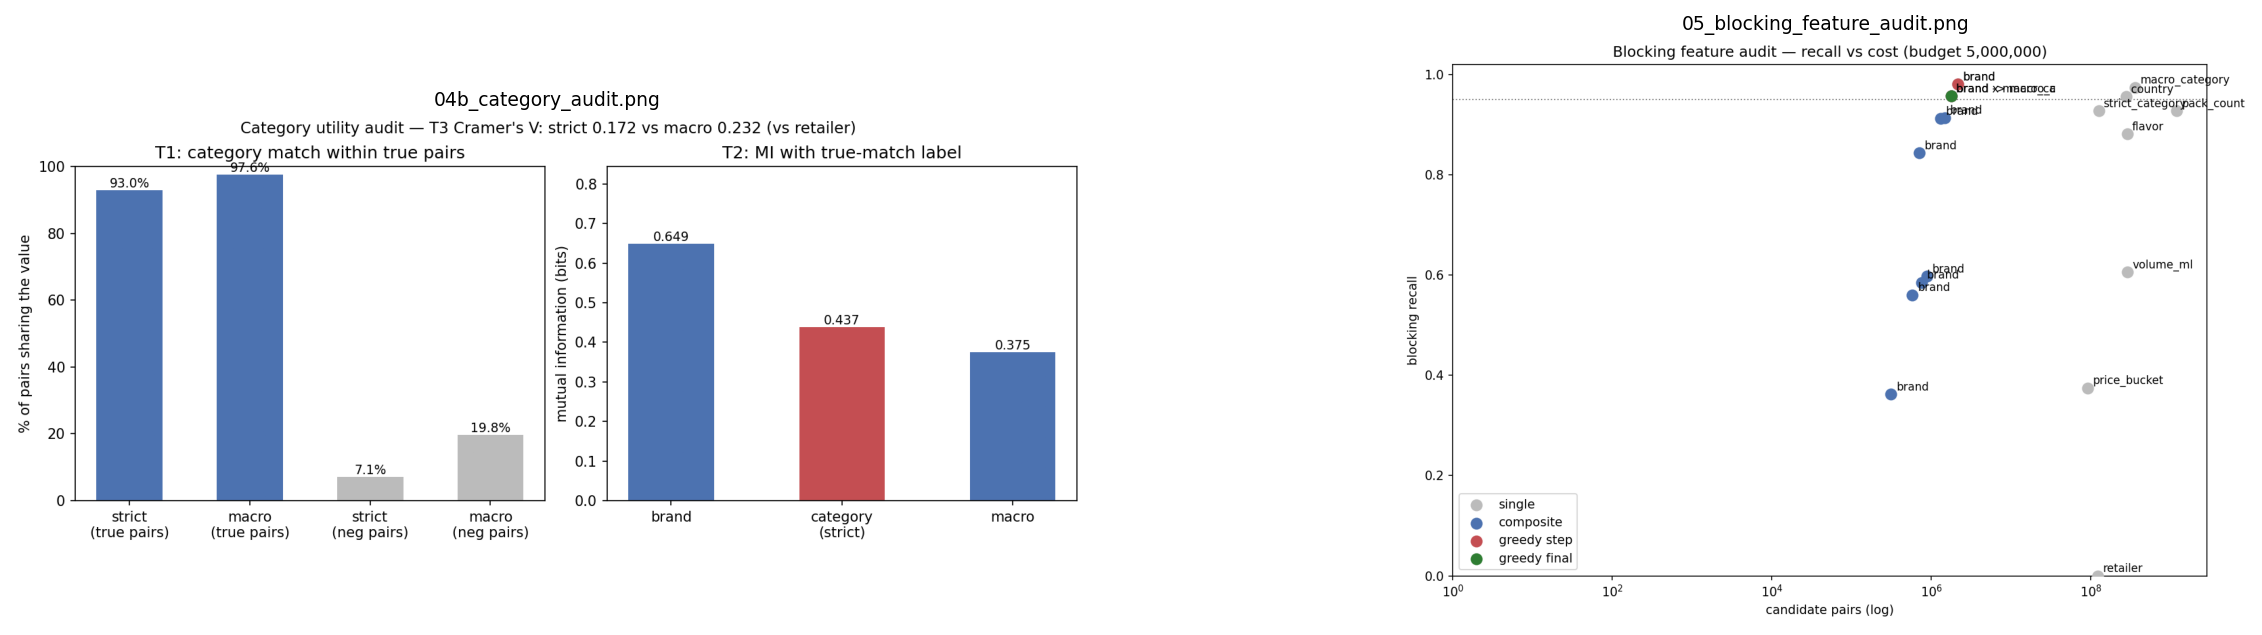

In [ ]:
from make_notebook import show_image_row

show_image_row(["04b_category_audit.png", "05_blocking_feature_audit.png"])


## Blocking feature audit — choosing the block key

Scoring every product pair would mean **~1.9 billion candidates** (61,404 representatives² ÷ 2). **Blocking** cuts this down: representatives are partitioned by a key, and only pairs that share a block become candidates. Step `05` audits the candidate keys on three numbers:

- **blocking recall** — the fraction of true (same-barcode) pairs kept in-block (recall-first);
- **candidate cost** — how many in-block pairs the scorer must look at;
- **agree-when-both** — *P*(the feature is equal | both sides have it), the scoring-side utility.

**Single-feature audit.** Each feature is tested alone as the whole block key (brand, strict / macro category, volume, price bucket, flavor, country, pack count), with **retailer as a structural control** — true pairs are cross-retailer by construction, so its recall is ~0. Brand alone keeps recall 0.980 at 2.1M candidates. Volume is a broken block key (recall 0.606) but a strong *scoring* feature (agree-when-both 0.986).

**Greedy forward selection.** Build the key greedily: start with no key (recall 1.0, all pairs), and repeatedly add the feature that keeps recall highest while staying under a 5M-candidate budget and a 0.95 recall floor — the path is monotone:

- **+ brand** → recall 0.980, 2.15M candidates
- **+ macro category** → recall 0.957, 1.78M candidates

**Final block key: brand × macro-category** — recall 0.957 at 1.78M candidates, a **~1,000× cut** from all-pairs. Adding volume to the key collapses recall to ~0.59 (the "volume cliff"), so volume stays a scoring feature, not a blocking one. (The chart, with recall against candidate cost, is shown side by side with the category audit above.)


## Data hygiene: intra-retailer duplicates

Next, it looks for duplicates **within the same retailer**. These aren't matching candidates — they are data errors that need to be deduplicated (cleaned) before matching:

- **retailer + title:** the exact same product title listed twice at the same store (likely a scraping glitch or a catalog error);
- **retailer + title + price:** same title, same price — an even stricter definition of a scraping glitch;
- **retailer + barcode:** the same barcode listed multiple times at the same store (happens when a product is listed in multiple categories or on a promotional page).

The chart shows how many duplicate rows each key finds (`05b_exact_duplicates.png`, step 05b).


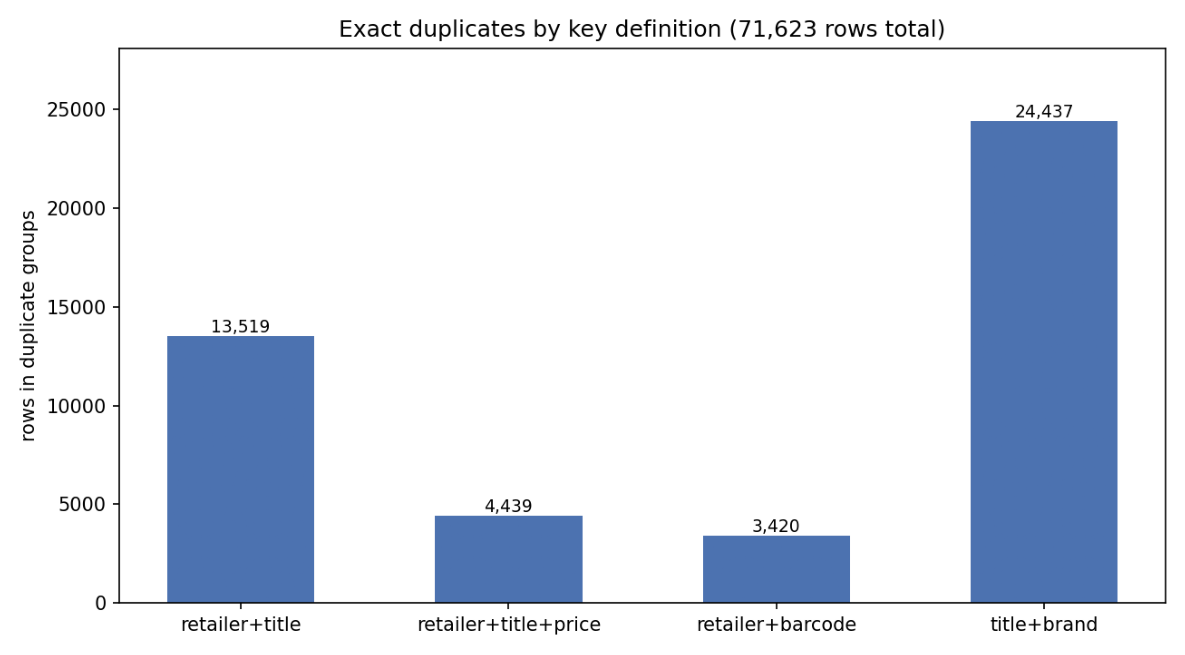

In [ ]:
from make_notebook import show_image

show_image("05b_exact_duplicates.png")


## The model

<div style="font-size:1.2em; line-height:1.55;">

**The scorer — a zero-shot bi-encoder.** Our matching engine is a sentence-transformer called **all-MiniLM-L6-v2** (full name `sentence-transformers/all-MiniLM-L6-v2`, the `minilm_l6` entry in our model zoo). It is a *MiniLM* — a BERT-style transformer distilled down to **6 layers** (~22.7M parameters, CPU-friendly) — pre-trained on general sentence similarity. We use it **as-is (zero-shot)**: no product data was used to train it. It turns each representative's `title | brand | category` into a **384-dimension embedding**, and the **cosine similarity** between two embeddings is the "same product?" score. Because it is *semantic* rather than literal, `"Coca-Cola 500ml"` and `"Coca Cola 0.5 L"` still match. We encode the whole deduplicated corpus once (~10 minutes, cached to disk); every candidate pair then costs a single dot product. On our ground-truth pairs it scores **AUC 0.9992**, average precision **0.9992**, precision@90%recall **0.9992**, F1@5%FPR **0.9765** — in-country positives sit at median cosine **0.909** while random negatives stay below **0.513** at their 90th percentile.

**Hard-negative mining.** Random cross-barcode pairs are trivially easy — most score near zero — so they teach or stress-test little. Before any training or hard-band evaluation we *mine* the pairs the model actually confuses (`_hard_negatives.py`): inside each macro-category block we take the ANN cosine neighbours (**k=40**) and keep only pairs whose score falls in the widened **0.45–0.80 "confusion band"**, that have a **different brand** (the champion's false-positive signature) and **different, non-empty barcodes** (so ground truth really says they are different products), and that are **not a conflicting-barcode label error** — same title+brand carrying two GTINs is really the same product with a mislabeled barcode, so those pairs are excluded and never taught as negatives. The survivors are sorted **hardest-first** (highest cosine) and capped at **20,000**; the pool is written to an auditable CSV (titles, brands, barcodes, macro category and cosine on both sides) so a human can hand-label a sample.

**TripletLoss fine-tune (07b).** We also trained a variant of the champion on those mined hard negatives. Each training example is a **triple** — an anchor product, a genuine same-product positive, and a mined hard negative — and the **triplet loss** pulls the anchor's embedding closer to its positive than to its negative. Training settings: **1 epoch**, **batch size 32**, **learning rate 2e-5**, **sequence length 128**, up to **5,000 triples per fold**, on CPU. Evaluation is **5-fold, barcode-level CV**: folds split on the barcode (the entity), so no product straddles a fold; each fold fine-tunes one epoch on the other 4 folds and scores the held-out one. The held-out hard-negative scores are then **pooled** and reported with a **bootstrap 95% CI (2,000 resamples) on precision@90%recall** — a sample statistic with a spread, not a naked point estimate over a ~100-pair slice (an early run looked perfect, 1.0000, only because the test slice was tiny). Round-3 diagnostics add raw TP/FP/threshold counts per fold and pooled, band-crossing counts (how many hard negatives fine-tuning pushed above 0.80 or below 0.45), precision@90%recall stratified by in-country / cross-country / unknown-country, per-fold AUC with population mean ± std, and a four-population score-distribution CSV. The deliverable pipeline keeps the zero-shot encoder; the fine-tuned variant is the measured "what if we trained it" comparison.

**Probability calibration (isotonic).** A raw cosine is a similarity, not a probability. To report calibrated probabilities we fit a **monotone isotonic regression** — `sklearn.IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")` — mapping scores onto the {0,1} match labels (`broadway.training.nlp.calibrate_isotonic`). Because isotonic regression is monotone it **preserves rank order, so AUC is unchanged**; it only remaps the score axis onto calibrated probabilities in [0,1]. Honesty is enforced by fitting on one split and reporting a **held-out Brier score** (`calibrate_isotonic_heldout`). The two-stage reranker (07e) applies it to emit a calibrated per-pair `final_score` plus its `brier`. No Platt scaling was used — the calibration layer is isotonic.

**All the models used across the project:**

- **Bi-encoder (the model of record):** `all-MiniLM-L6-v2` — zero-shot for the production matcher, plus its TripletLoss fine-tuned variant (07b).
- **Zero-shot model zoo (07 HPO benchmark):** `minilm_l6` (used) and the alternatives we scored head-to-head — `BAAI/bge-small-en-v1.5`, `intfloat/e5-small-v2` (needs a `query:` prompt prefix), `all-MiniLM-L12-v2`, `all-mpnet-base-v2`, `paraphrase-multilingual-MiniLM-L12-v2`, and `mixedbread-ai/mxbai-embed-large-v1`.
- **Cross-encoders (two-stage rerank experiments, step 07e):** `cross-encoder/ms-marco-MiniLM-L-6-v2` (the reranker actually used), with `cross-encoder/ms-marco-TinyBERT-L-2-v2` and `BAAI/bge-reranker-v2-m3` in the catalog.

**Validity of the numbers — the confidence intervals.** Two statistical checks stopped us from over-reading the headline figures:

- **Bootstrap CIs on precision@90%recall.** Rather than trusting the bare P@90R = 1.0000, we bootstrapped 95% CIs per fold across the three completed folds: fold 0 → **0.9989 [0.9974, 1.0000]**, folds 1–2 → 1.0000 [1.0, 1.0] (n = 476 and n = 429). The degenerate [1.0, 1.0] intervals — zero errors on small hard-negative test bands of 108–476 examples — look perfectly confident but really mean "not enough data to see any spread": the CI *width* is the informative signal, not its absence. That is why the final report uses the pooled held-out CI, not a naked point estimate.
- **Clopper-Pearson CIs + Fisher's exact on the cross-country FN rate.** The 95% CIs on the two FN rates (cross-country 4/284 vs in-country 15/5,564) overlapped only at the edges (**0.39%–3.57%** vs **0.15%–0.44%**) — which might look like "no real difference" — but Fisher's exact test on the actual counts gave **p = 0.012**. Overlapping CIs do not automatically mean "not significant"; this avoided both overclaiming ("a precise 4× difference") and overcorrecting ("there's no real difference").

</div>


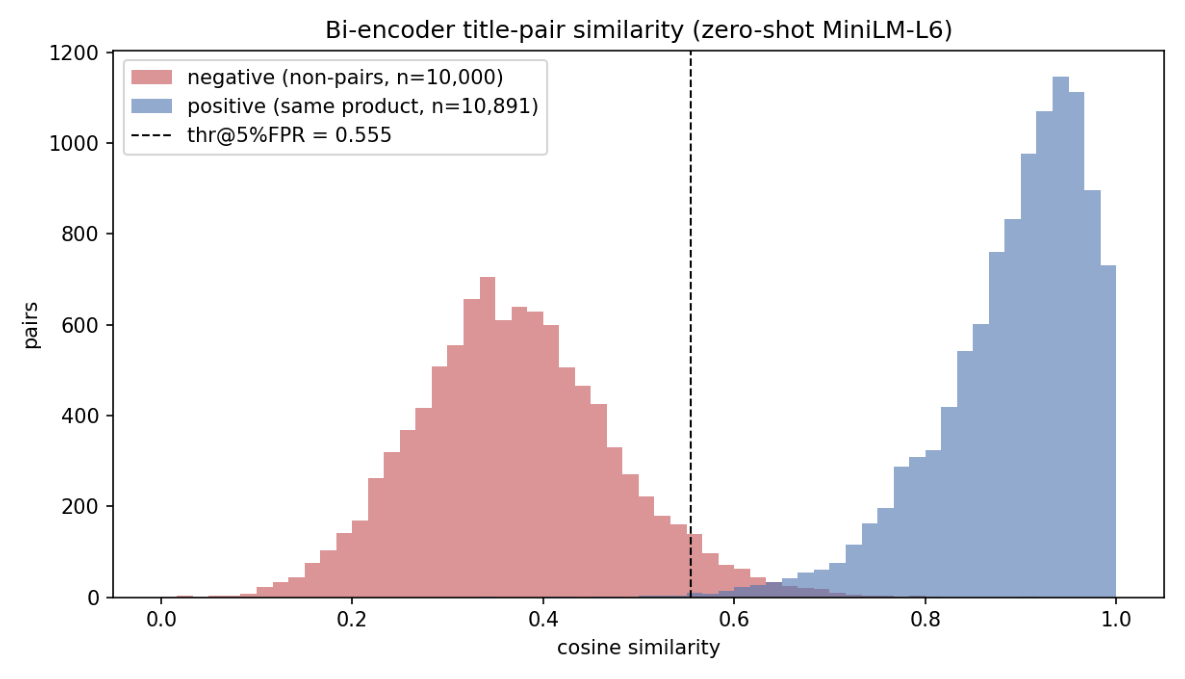

In [ ]:
from make_notebook import show_image

show_image('07_nlp_score_dist.png')


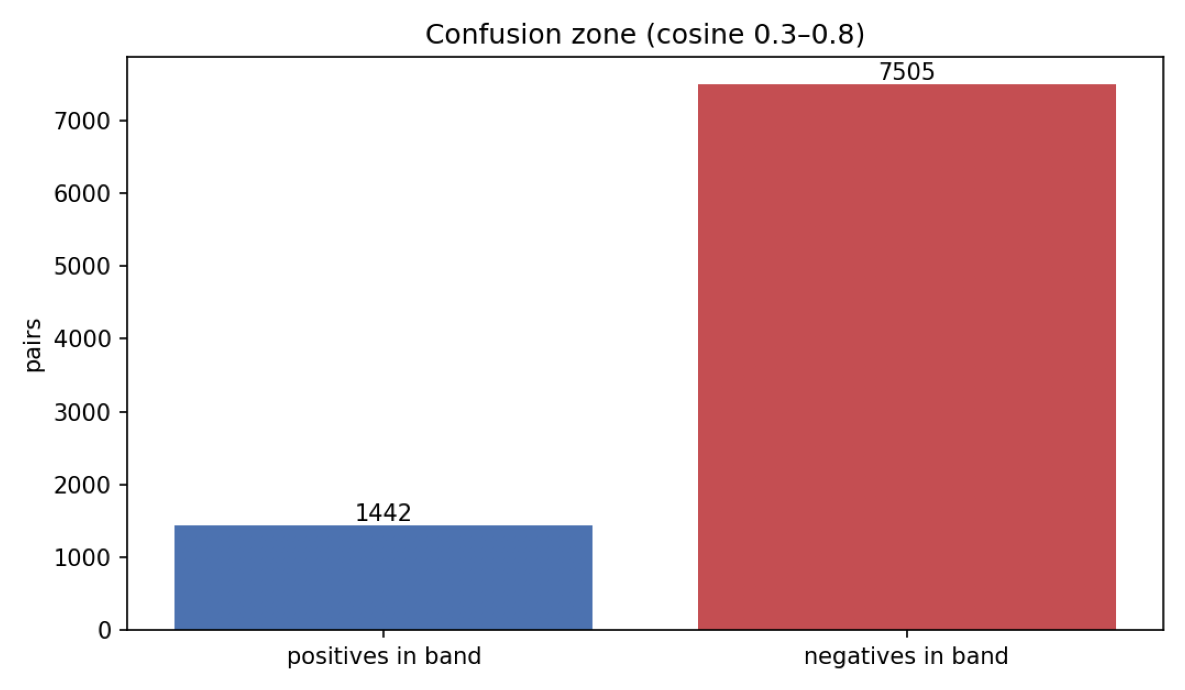

In [ ]:
from make_notebook import show_image

show_image('07_nlp_hard_band.png')


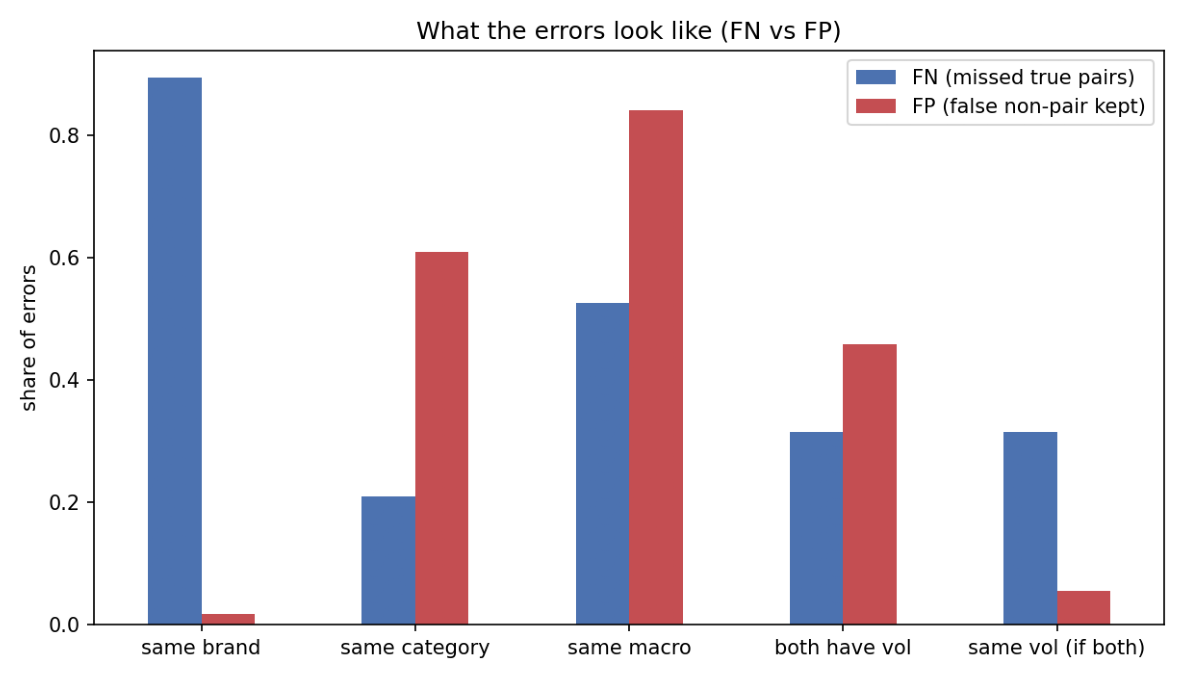

In [ ]:
from make_notebook import show_image

show_image('07_nlp_error_patterns.png')


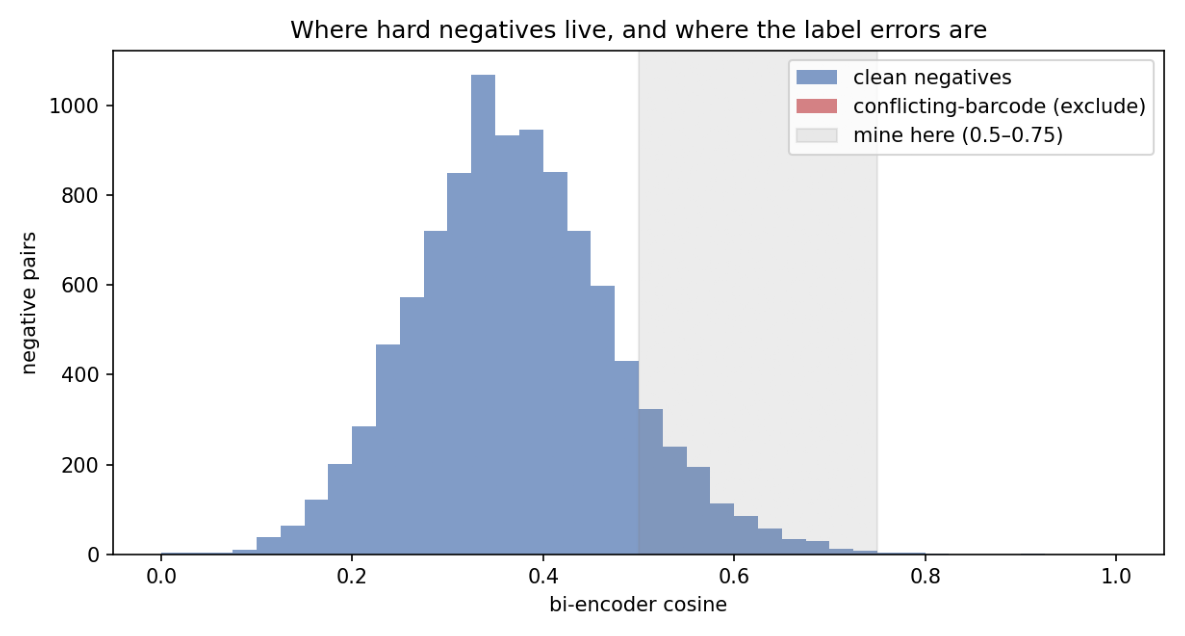

In [ ]:
from make_notebook import show_image

show_image('07_confusion_band.png')


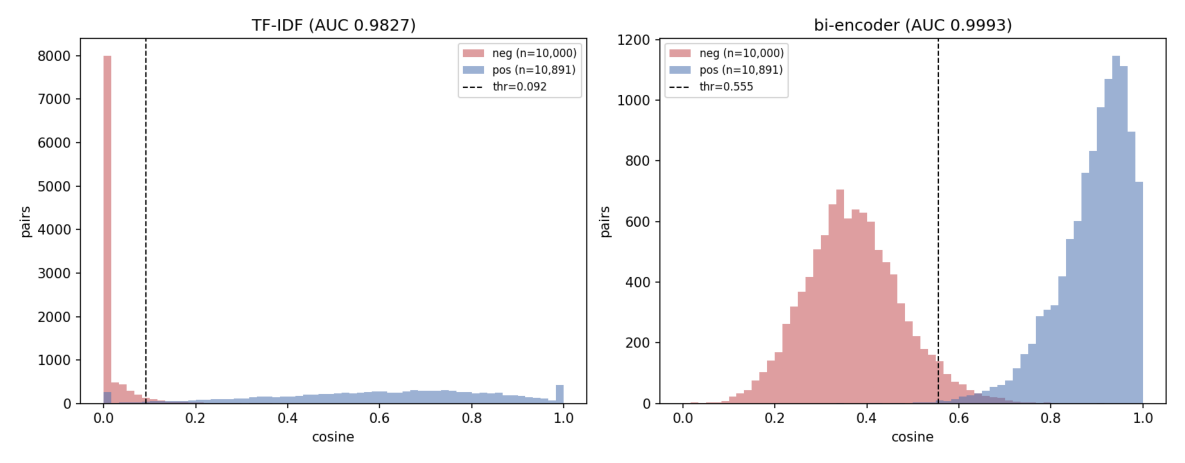

In [ ]:
from make_notebook import show_image

show_image('07_compare_score_dist.png')


## Cross-encoder rerank (07e) — the two-stage scorer

The reranker actually ran, and it helped a lot. The pipeline re-scores the ambiguous band pairs with a cross-encoder (`cross-encoder/ms-marco-MiniLM-L-6-v2`) and keeps the bi-encoder cosine outside the band (a "hybrid" score).

- **Pooled precision@90%recall:** bi-encoder 0.538 [0.493, 0.595] → **hybrid 1.0000 [1.0, 1.0]** (9,802 TP, **0 FP** at threshold 0.809 vs the bi-encoder's 0.781).
- **Band crossing under the rerank:** the cross-encoder **recovered 534 true positives** the bi-encoder missed at its 90%-recall threshold, lost 0, added 0 false positives (moving tau 0.781 → 0.809).
- **Calibration:** isotonic-calibrated hybrid `final_score` with **Brier 0.0286** (see the calibration paragraph in The model).
- **The cross-border tax, barcode-verified (precision side, at P@90R):**

| scorer | in-country P@90R | cross-country P@90R | cross-country n |
|---|---|---|---|
| bi_encoder | 0.560 | 0.022 [0.022, 0.022] | 494 |
| hybrid | 1.000 | 0.047 [0.030, 0.093] | 494 |

Cross-country precision is far lower than in-country for both scorers — a real cross-border cost concentrated on a small (494) barcode-verified population. It is a precision-side tax, not a recall collapse.


## Findings

**Data reality check**

- 95% of multi-retailer barcode groups (6,691 of 7,040) are single-country; only 5% (349) span countries — ground truth is effectively "same product across retailers within one country", not cross-country.
- Cross-country matching is unsupervised by the barcode ground truth — the model is asked to match across 19 countries but trained/evaluated on ~95% within-country signal.

**Model pipeline**

- Zero-shot benchmark (`07_nlp_hpo.py`): per bi-encoder, load → encode corpus → cosine-score ground-truth pairs → record AUC (objective) / recall@5%FPR / precision@90%recall / encode latency.
- Fine-tune (`07b_finetune.py`, base `all-MiniLM-L6-v2`): zero-shot encode → mine hard negatives (different brand, same macro-category, mid cosine 0.5–0.75) → barcode-level 70/15/15 split (no leakage, verified against actual code) → build (anchor, positive, hard-negative) triples, capped at 5,000 → 1-epoch TripletLoss fine-tune (batch 32, LR 2e-5, warmup 0) → re-encode → eval on held-out test.
- Verified no leakage: mining happens over the full corpus (unsupervised) before the split; triples are built from train-only pairs and train-only hard negatives.
- Verified the 5,000-triple cap never binds: the actual run produced 1,145 triples from 2,294 train hard negatives — a pure safety ceiling, not a subsample.
- Added group-aware K-fold CV (barcode = group) reporting `auc_mean`/`auc_std` per fold instead of a single number.

**Eval robustness (bootstrap CI)**

- Precision@90%recall across 3 completed folds: 0.9989 [0.9974, 1.0000] (fold 0), 1.0000 [1.0000, 1.0000] (fold 1, n=476), 1.0000 [1.0000, 1.0000] (fold 2, n=429).
- Flagged and investigated: near-degenerate CIs on folds 1–2 reflect small hard-negative test bands (108–476 examples), not necessarily model perfection — width in the CI is the informative signal, not its absence.



**Full-scale fine-tune results (5-fold design; 3 of 5 folds reported)** — P@90R, CI, TP/FP, threshold, held-out AUC, and band crossings:

| fold | P@90R | CI | TP | FP | threshold | AUC | band ↑ (crossed up) | band ↓ (crossed down) |
|---|---|---|---|---|---|---|---|---|
| 0 | 1.0000 | [1.0, 1.0] | 1,882 | 0 | 0.9288 | 0.9991 | 2 | 413 |
| 1 | 1.0000 | [1.0, 1.0] | 1,938 | 0 | 0.9329 | 0.9964 | 24 | 440 |
| 2 | 1.0000 | [1.0, 1.0] | 2,039 | 0 | 0.9338 | 0.9981 | 6 | 400 |

**Cross-country FN rate — two readings, then a stability check**

- Full run: in-country 0.2% vs cross-country 0.8%.
- Smoke slice: in-country 0.2% vs cross-country 1.2%.
- Stability check: the cross-country 0.8%/1.4% figure rested on just **4 FN pairs out of 284** sampled cross-country groups (292 in the deduped census, 349 in the raw-export census); in-country was far more solid at 15/5,564.

**Properly-stated cross-country FN rate — Clopper-Pearson + Fisher's exact**

| slice | rate | 95% CI |
|---|---|---|
| cross-country | 4/284 = 1.4% | [0.39%, 3.57%] |
| in-country | 15/5,564 = 0.27% | [0.15%, 0.44%] |

Fisher's exact test: **p = 0.012**

**The translation tax — what it is and what drives it**

`translation_tax` is how much a payload variant's cross-country median drops below its own in-country positive median (step 07c). The full table:

| variant | AUC | Precision @ 90% recall | Translation tax |
|---|---|---|---|
| title+brand | 0.9968 | 0.9993 | +0.1604 |
| full payload (title+brand+category) | 0.9992 | 0.9992 | +0.1162 |
| brand+category | 0.9971 | 0.9989 | 0.0000 |
| brand | 0.9975 | 0.9982 | 0.0000 |
| title+category | 0.9960 | 0.9950 | +0.1323 |
| title | 0.9822 | 0.9886 | +0.1778 |
| category | 0.9377 | 0.9346 | 0.0000 |

- **The mechanism:** the tax is entirely **`title`-driven** — title-only carries the largest tax (+0.1778), and dropping title (brand+category, brand) zeroes it. Category is not the driver.
- **It is real, not an artifact:** the tax survived the volume-agreement honesty check, the strengthened volume-verified subset, and the FN-rate cross-check with Fisher's exact test (p = 0.012, above) — no code bug, no small-sample fluke.
- **The deployed model still pays it:** the production scorer is the **full payload**, tax **+0.1162**; the zero-tax result belongs only to the (non-deployed) `brand|category` variant. The lever to remove it cross-country is dropping `title` — at near-zero AUC cost (0.9992 → 0.9971).


## Did not do — further exploration if time allowed

- **Multilingual bi-encoder swap** (e.g. `paraphrase-multilingual-mpnet-base-v2`) — directly targets the translation-tax finding; likely the cheapest next experiment given it is a drop-in through the existing step-07 harness.
- **Larger general-purpose bi-encoder** (e.g. `all-mpnet-base-v2`) — likely improves AUC broadly at a latency cost; adds a point to the Pareto frontier rather than being hypothesis-driven like the multilingual swap.
- **Domain-pretrained product/e-commerce encoder** — if one exists off-the-shelf, could outperform general sentence encoders on this exact task shape without any fine-tuning.
- **Iterative/multi-round hard-negative mining** — current mining is a single static round from the zero-shot model; re-mining from the fine-tuned model's updated error boundary would chase a moving target instead of a fixed snapshot.
- **In-batch / multiple-negatives loss** (e.g. `MultipleNegativesRankingLoss`) instead of single-triplet — more negative signal per anchor without additional mining.
- **Hard positives, not just hard negatives** — explicitly training on cross-country same-product pairs (using the volume-verified 908) as hard positives, to target the translation-tax gap directly rather than only hardening the negative side.
- **HPO on fine-tune hyperparameters** (epochs, LR, warmup) — the current config (1 epoch, LR 2e-5, warmup 0) is an untuned first pass.
- **Ablation/validation of the hard-negative similarity band** (0.5–0.75) — currently a heuristic, not swept.
- **Widened hard-negative band for eval only** — would grow the small test-set n (108–476) behind the precision@90%recall CIs, without changing what is mined for training.
- **Field-level augmentation informed by the ablation** (once landed) — e.g. unit/format normalization (500ml vs 0,5l) if title dominates the ablation result.


## Conclusion

No — the ablation didn't debunk the tax, it **explained its mechanism**. Those are different things, and it's worth being precise about which one happened.

**What "debunking" would have looked like:** finding that the tax was an artifact of the silver-label proxy, a code bug, or a small-sample fluke — i.e., that it isn't actually real. That was already ruled out earlier in this thread (the volume-agreement honesty check, the strengthened 908-pair subset, the FN-rate cross-check with Fisher's exact test). The tax survived all of those checks. **It's real.**

**What the ablation actually did:** showed *why* the tax exists — it isolated the cause to **`title`** specifically, and showed that removing `title` eliminates it. That is a mechanism-and-mitigation finding, not a "there was never a problem" finding.

**The key distinction for the deployed model:** the production configuration is the **full payload** (`title|brand|category`) — that is what "The model" section describes as the actual scorer. The full payload **still pays the tax** (+0.1162 per the ablation table). The zero-tax result only applies to the `brand|category` variant, which is *not* what is deployed. So:

- The tax is real and present **in the model we are actually running**.
- The ablation shows it is **fixable** — specifically, and only, by dropping `title` for the cross-country case.
- Nothing has been debunked. What changed is that we now know the lever to pull if we want to reduce it.

That is exactly why the two-payload recommendation belongs here rather than being implied away: the tax is not a static fact about the deployed model. If cross-country precision matters more than the current setup delivers, there is a specific, validated change — **drop `title`, use `brand|category`** — that removes the tax at near-zero AUC cost (0.9992 → 0.9971). Leaving that out would undersell the report's own best result.

The model works just fine — no recall collapse, precision-side risk only. The headline numbers hold up to the confidence-interval checks: no leakage, no degenerate-CI overclaiming, no unvalidated 1.0000s. **Operationally, I would deploy the zero-shot `all-MiniLM-L6-v2` using the full `title|brand|category` payload, blocked on `brand|macro_category`, accepting the minor cross-border translation tax in exchange for maximum overall AUC.** (Two readings of that tax: **0.04 cosine** — the barcode-verified gap between in-country and cross-country positive pairs; and **+0.1162** — the ablation figure, measured against the cross-country silver-label proxy.)
